In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xraydb

from numpy.polynomial.legendre import leggauss

In [8]:
# point source
def E(x,y,D):
    return D/(x**2 + y**2 + D**2)**(3/2)

# distributed source
import numpy as np
from numpy.polynomial.legendre import leggauss

def E_disk(x, y, D, r_s, q=1.0, N=256):
    """
    Irradiance at (x,y) on plane z=D from a uniform circular disk source (radius r_s) at z=0.
    Isotropic emission. Per-unit source power density q.
    v is integrated analytically; u via Gauss–Legendre (N nodes).
    """
    X, Y = np.broadcast_arrays(np.asarray(x, float), np.asarray(y, float))

    xi, wi = leggauss(N)         # nodes/weights on [-1,1]
    u = r_s * xi                 # map to [-r_s, r_s]
    w = r_s * wi

    # Broadcast to (N, *X.shape)
    u_b = u.reshape(N, *([1]*X.ndim))
    w_b = w.reshape(N, *([1]*X.ndim))
    Xb = X[None, ...]
    Yb = Y[None, ...]

    s = np.sqrt(r_s*r_s - u_b*u_b)         # √(r_s^2 - u^2)
    A = D*D + (Xb - u_b)**2

    w2 =  s - Yb
    w1 = -s - Yb

    term = (w2 / np.sqrt(A + w2*w2)) - (w1 / np.sqrt(A + w1*w1))
    integrand = (D / A) * term

    E = (q / (4.0 * np.pi)) * np.sum(w_b * integrand, axis=0)
    return E.item() if E.shape == () else E

def t_eff(x, y, D):
    return np.sqrt(x**2 + y**2 + D**2)/D

def transmission(x, y, D, t=200e-6):

    t_eff = t*np.sqrt(x**2 + y**2 + D**2)/D
    mu = xraydb.material_mu('Quartz', 14.4e3)  * t_eff * 100

    return np.exp(-mu) 
    
np.exp(-xraydb.material_mu('Quartz', 14.4e3)  * 200e-6 * 100)

1.285*25.4

32.638999999999996

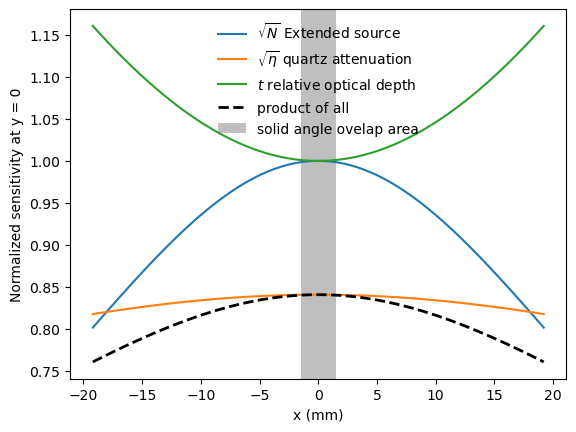

In [ ]:


r_s = 3e-3  # radious of source active spot
d_a = 21.8e-3#16e-3 distance of absober from source
d_c = 32.6e-3#21e-3 # distance of camera from source
t_quartz = 200e-6 # quartz thickness
r_o = r_s*(d_c/d_a-1) # radious of overlap region (source conjugate on camera plane with rspect to the absorber plane )
H = 35.2e-3  # camera height
L = 38.4e-3  # camera width

x = np.linspace(-L/2, L/2, 100)
y = 0



point_source_norm = np.sqrt(E(x,y,d_c)/E(0,0,d_c))
extended_source_norm = np.sqrt(E_disk(x,y,d_c,r_s)/E_disk(0,0,d_c,r_s))
effective_thickness_norm = (t_eff(x,y,d_c)/t_eff(-0,0,d_c))
transmission_quartz = np.sqrt(transmission(x,y,d_c,t_quartz))

#plt.plot(x*1e3, point_source_norm, label='$\sqrt{N}$ point source')
plt.plot(x*1e3, extended_source_norm, label = '$\sqrt{N}$ Extended source')
plt.plot(x*1e3, transmission_quartz, label='$\sqrt{\eta}$ quartz attenuation')
plt.plot(x*1e3, effective_thickness_norm, label='$t$ relative optical depth')

product = extended_source_norm*effective_thickness_norm*transmission_quartz
# plt.plot(x*1e3,effective_thickness_norm*transmission_quartz, 'k.', label='total')
plt.plot(x*1e3,product, color = 'k',linestyle = '--', linewidth =2 , label='product of all')


plt.axvspan(-r_o*1e3,r_o*1e3, color='gray', linewidth = 0, alpha = 0.5, label ='solid angle ovelap area')
#plt.axvline(r_o*1e3, color='gray', linestyle='--')
plt.legend(frameon=False)
#plt.ylim(0, 1.5)
plt.xlabel('x (mm)')
plt.ylabel('Normalized sensitivity at y = 0')
plt.show()


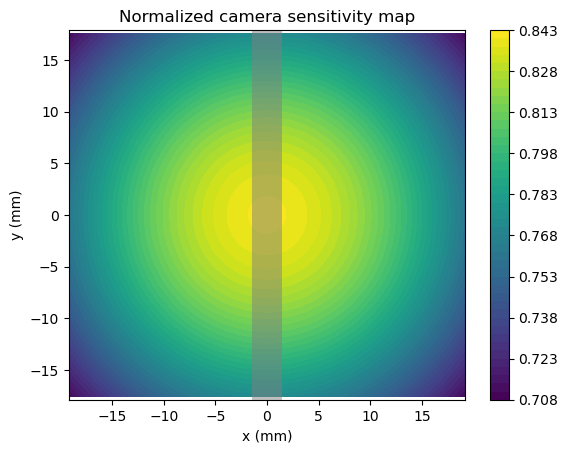

In [10]:

x = np.linspace(-L/2, L/2, 100)
y = np.linspace(-H/2, H/2, 100)
X, Y = np.meshgrid(x, y)

#point_source_norm = np.sqrt(E(X,Y,d_c)/E(0,0,d_c))
extended_source_norm = np.sqrt(E_disk(X,Y,d_c,r_s)/E_disk(0,0,d_c,r_s))
effective_thickness_norm = t_eff(X,Y,d_c)/t_eff(0,0,d_c)
transmission_quartz = np.sqrt(transmission(X,Y,d_c,t_quartz))

Z = extended_source_norm
Z = extended_source_norm*effective_thickness_norm*transmission_quartz

plt.contourf(X*1e3, Y*1e3, Z, levels=50, cmap='viridis')
plt.axvspan(-r_o*1e3,r_o*1e3, color='gray', linewidth = 0, alpha = 0.5, label ='solid angle ovelap area')

plt.colorbar()
plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Normalized camera sensitivity map')
plt.axis('equal')

plt.show()

In [14]:
32.6e-3 - 21.8e-3

0.010799999999999997

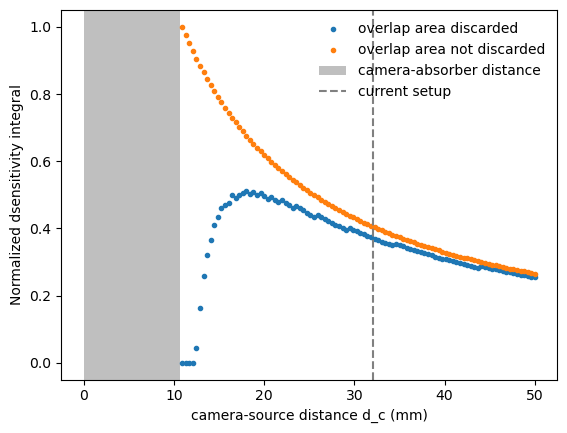

In [20]:
# now for different distances integrate to see the relevant figure of merit
# only integrate from -w/2 to to -r_o
d_ac = 10.7e-3

distances = np.linspace(d_c-d_a, 50e-3, 100)

integral = []
integral0 = []
r_o_list = []

for d_c in distances:
    d_a = d_c - d_ac 
    r_o = r_s*(d_c/d_a-1)
    x = np.linspace(-L/2, L/2, 100)
    y = 0
    dx = x[1]-x[0]

    extended_source_norm = np.sqrt(E_disk(x,y,d_c,r_s))
    effective_thickness_norm = t_eff(x,y,d_c)
    transmission_quartz = np.sqrt(transmission(x,y,d_c,t_quartz))

    integrand = extended_source_norm * effective_thickness_norm * transmission_quartz
    mask = (x >= -L/2) & (x <= -r_o)
    integral.append(np.trapz(integrand[mask], x[mask]))
    mask0 = (x >= -L/2) & (x <= 0)
    integral0.append(np.trapz(integrand[mask0], x[mask0]))
    r_o_list.append(r_o)

plt.plot(distances*1e3, integral/integral0[0],'.', label='overlap area discarded')
plt.plot(distances*1e3, integral0/integral0[0],'.',label='overlap area not discarded')
plt.axvspan(0,(d_c-d_a)*1e3, color='gray', linewidth = 0, alpha = 0.5, label ='camera-absorber distance')


plt.axvline(32, color='gray', linestyle='--', label='current setup')
#plt.ylim(0,1)
plt.xlabel('camera-source distance d_c (mm)')
plt.ylabel('Normalized dsensitivity integral')
plt.legend(frameon=False)


In [23]:
# nov for different distances integrate to see the relevant figure of merit
# only integrate from -w/2 to to -r_o
d_ac = 10.7e-3

distances = np.linspace(d_c-d_a, 50e-3, 100)

integral = []
integral0 = []
r_o_list = []

for d_c in distances:
    d_a = d_c - d_ac 
    r_o = r_s*(d_c/d_a-1)
    
    x = np.linspace(-L/2, L/2, 300)
    y = np.linspace(-H/2, H/2, 300)
    X, Y = np.meshgrid(x, y)

    dx = x[1]-x[0]

    extended_source_norm = np.sqrt(E_disk(X,Y,d_c,r_s))
    effective_thickness_norm = t_eff(X,Y,d_c)
    transmission_quartz = np.sqrt(transmission(X,Y,d_c,t_quartz))
    Z = extended_source_norm*effective_thickness_norm*transmission_quartz


    #integrand = Z[np.argmin(np.abs(y)),:]
    integrand = Z.mean(axis=0)

    mask = (x >= -L/2) & (x <= -r_o)
    integral.append(np.trapz(integrand[mask], x[mask]))
    mask0 = (x >= -L/2) & (x <= 0)
    integral0.append(np.trapz(integrand[mask0], x[mask0]))
    r_o_list.append(r_o)


0.7545807856064511

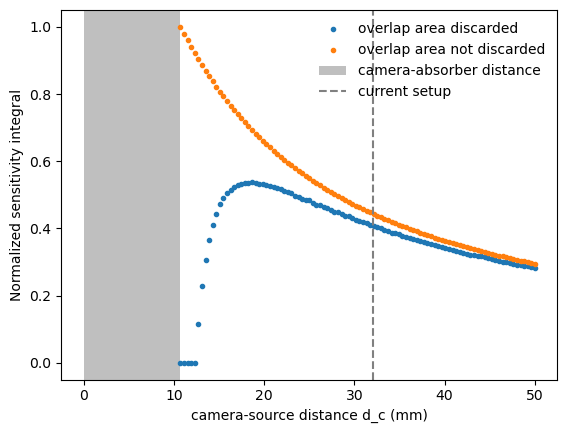

In [24]:

plt.plot(distances*1e3, integral/integral0[0],'.', label='overlap area discarded')
plt.plot(distances*1e3, integral0/integral0[0],'.',label='overlap area not discarded')
plt.axvspan(0,(d_c-d_a)*1e3, color='gray', linewidth = 0, alpha = 0.5, label ='camera-absorber distance')

plt.axvline(32, color='gray', linestyle='--', label='current setup')
#plt.ylim(0,1)
plt.xlabel('camera-source distance d_c (mm)')
plt.ylabel('Normalized sensitivity integral')
plt.legend(frameon=False)

integral[np.argmin(np.abs(distances-32e-3))]/np.max(integral)


Text(0, 0.5, 'spatial resolution/overlap area width/ (mm)')

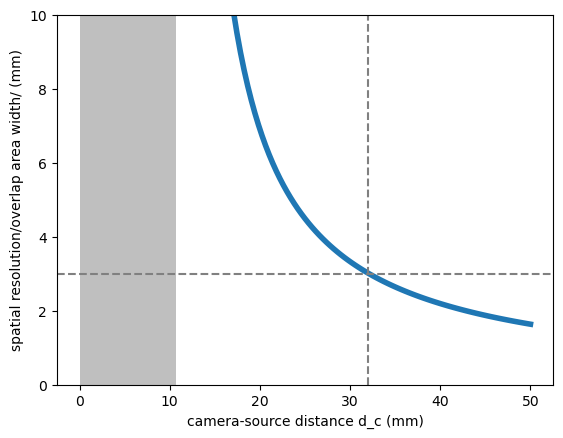

In [26]:
plt.plot(np.array(distances)*1e3, 2*np.array(r_o_list)*1e3,linewidth=4)
#plt.plot(np.array(distances)*1e3, 1/np.array(distances)**2/1000)
d_line = 32e-3
plt.axvline(d_line*1e3, color='gray', linestyle='--')
plt.axhline(2*r_o_list[np.argmin(np.abs(distances - d_line))]*1e3, color='gray', linestyle='--')

#d_line = 30e-3
#plt.axvline(d_line*1e3, color='gray', linestyle='--')
#plt.axhline(r_o_list[np.argmin(np.abs(distances - d_line))]/L*100, color='gray', linestyle='--')

plt.axhline
plt.ylim(0,10)

r_o_list[np.argmin(np.abs(distances - d_line))]*1e3
plt.axvspan(0,(d_c-d_a)*1e3, color='gray', linewidth = 0, alpha = 0.5, label ='camera-absorber distance')

plt.xlabel('camera-source distance d_c (mm)')
plt.ylabel('spatial resolution/overlap area width/ (mm)')


0.9167595985033541


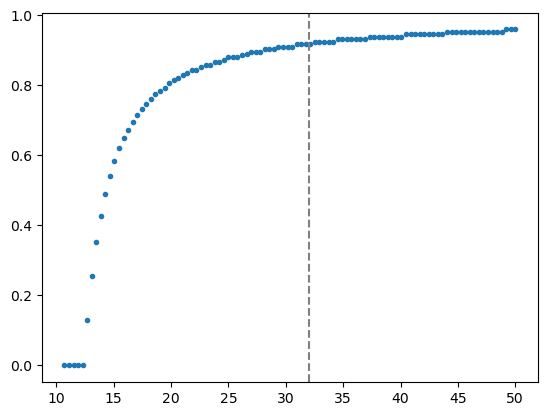

In [27]:
#ACTUAL LOSS OF SENSITIVITY beacuse of area overlap
plt.plot(distances*1e3, np.array(integral)/np.array(integral0),'.')
plt.axvline(32, color='gray', linestyle='--')


#at distance of 32 mm the efficiency is:
idx = np.argmin(np.abs(distances - 32e-3))
print(integral[idx]/integral0[idx])

Text(0, 0.5, 'spatial resolution/overlap area/ (mm)')

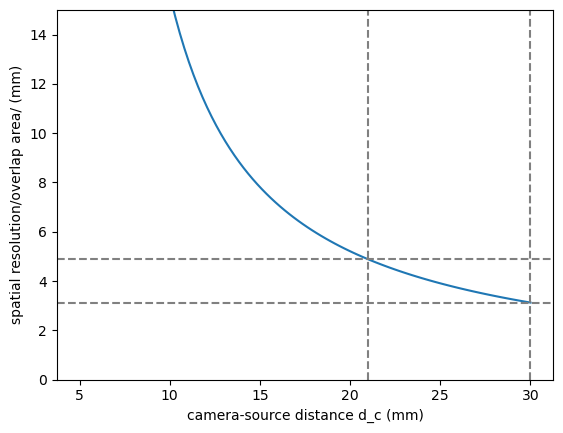